# Calculate wind speed/wind stress magnitude from submonthly vector data, for specified time/space domain 
## calculate statistitcal moments (mean, std, max) for each month


data source etc

In [1]:
#src = 'JRA55-do-1.4'
#vNam = ['uas','vas'] ;
#diri = '/g/data/ik11/inputs/JRA-55/MRI-JRA55-do/MRI-JRA55-do-1-4-0/atmos/'

ovNam = 'windspeed'

src = 'ERA5'
diri = '/g/data/rt52/era5/single-levels/reanalysis/' 
vNam = ['u10','v10'] ; 
#unfortunately on gdata they switched the variable on the filenammes from u10 to 10u
#so a cludgey extra file-variable-name is required. Because otherwise it would be easy and logical
fvNam = ['10u','10v'] 


#ovNam = 'wind stress magnitude'


#time and space domain
clst = 2000 ; clen = 2025 
anom_year = 2023
month = [5,6,7]
latmin = -90. ; latmax = -50. 


#output file
diro = '/g/data/jk72/wrh581/'
filo = src+'_'+ovNam+'_stats_'+str(anom_year)+'.png'

In [2]:
#imports
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import numpy as np
import xarray as xr
import cf_xarray as cf
import pandas as pd
import cartopy.crs as crs
import cartopy as ccrs
import subprocess


import dask
from dask.distributed import Client
Client=Client()

Read hourly wind components 
reduce to timescale of interest

In [3]:
#clunky piece of code to get a concatenated list of years 
#usefule when searching for a subset of files
yrst = np.min([clst, anom_year]) ; yren = np.max([clst, clen])
if yrst == yren:
    yrstr = str(yrst)
else:
    yrstr = [str(int) for int in  np.arange(yrst, 1+yren) ] 
    yrstr ='{'+','.join(yrstr)+'}'

    
#function to read data and reduce time


def read_wind(fvar, var):
    if src == 'ERA5':
        CMD = 'ls '+diri+fvar+'/'+yrstr+'/'+fvar+'_era5_oper_sfc_*.nc' 
    else:
        CMD = 'ls '+diri+fvar+'/'+fvar+'_input4MIPs_atmosphericState_OMIP_MRI-JRA55-do-1-4-0_gr_'+yrstr+'*.nc'
        
    fili = subprocess.run(CMD, shell=True, capture_output=True)  #run CMD as a bash command
    fili = fili.stdout.decode().split('\n')[0:-1] 

    data = xr.open_mfdataset(fili, 
                             combine="by_coords",
                             parallel = True, 
                             chunks = {'time' : 744}
                        )    
    
    #spatial coords may be names 'lat,lon' or <latitude,longitude>
    out  = data[var].cf.sel(latitude = slice(latmax,latmin))
    out  = out.isel(time = out.time.dt.month.isin(month))

    return out


U = [read_wind(fvNam[0],vNam[0]),
     read_wind(fvNam[1],vNam[1])]


chunks = {U[0].cf['time'].name : 31 * 24,
          U[0].cf['latitude'].name : -1,
          U[0].cf['longitude'].name : 360}

for i in [0,1]:
    U[i] = U[i].chunk(chunks)

### Calc wind speed

In [7]:
#stay 

speed = xr.apply_ufunc(
    np.hypot,
    U[0],
    U[1],
    dask='parallelized',
    output_dtypes=[np.float32]
)

#  enforce float32 to halve memory
speed = speed.astype('float32')


Get stats for each calendar month

In [9]:
# rechunk, so that each chiunk inclueds entire time dimension
#speed = speed.chunk({'time' : 744, 'latitude' : -1, 'longitude' : 360})


#resample only once
resampled = speed.resample(time= '1ME')
    
#cpmute BEFORE merging into a sigle dataset, so that the compute tasks are serialized/not all heppening at once
monmean = resampled.mean(('time')).compute()
monmax = resampled.max(('time')).compute()
monsd  = resampled.std(('time')).compute()


#create a dataset
vars_ = ['mean', 'max', 'sd']
stats = xr.Dataset({vars_[0] : monmean ,
                    vars_[1] : monmax,
                    vars_[2] : monsd})


clim = stats.sel(time = slice(str(clst),str(clen)))
anom = stats.sel(time = str(anom_year))

clim = clim.mean('time').compute()
anom = anom.mean('time').compute()




/g/data/xp65/public/apps/med_conda/envs/analysis3-26.04/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 23.35 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.04/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 23.35 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.04/lib/python3.12/site-packages/distributed/cli

In [47]:
anom = (anom - clim).compute()
clim_std = stats.sel(time = slice(str(clst),str(clen))).std('time')
anom_norm = (anom/clim_std).compute()

# Map plots

### top row shows abs anoms, bottom row normalised anoms

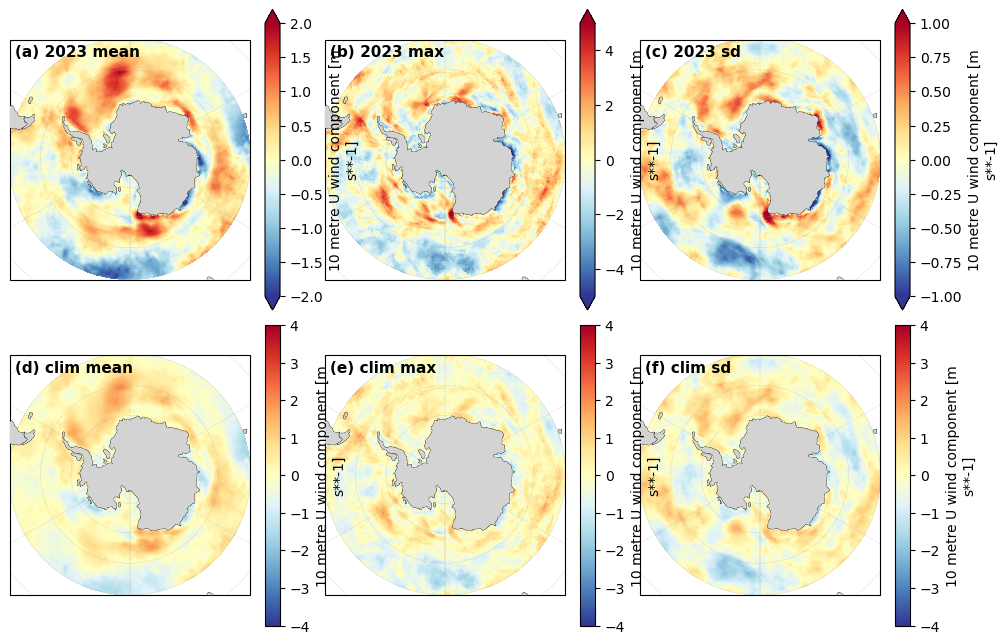

In [56]:

# PROJECTION
proj = crs.SouthPolarStereo()
data_crs = crs.PlateCarree()

# ======================
# COLOR map
# ======================

cmap = 'RdYlBu_r'


cmax=[[2.,5.,1.] ,  #anoms
      [4.,4.,4.]]   #normalised anoms


# =================
# panel set up
# ====================

nrow = 2; ncol = 3
fig, axes = plt.subplots(nrow, ncol, 
                         figsize=(12, 8),
                         subplot_kw={'projection': proj})

plt.subplots_adjust(wspace=0.05, hspace=0.05)

# Panel labels
panel_labels = ['(a) '+vars_[0], '(b) '+vars_[1], '(c) '+vars_[2],
                               '(d) norm '+vars_[0], '(e) norm '+vars_[1], '(f) norm '+vars_[2]] 

# ======================
# PLOTTING LOOP
# ======================

def mapplot (panel_axes, plot_data,  maxlev):
    ax = panel_axes

    im = plot_data.plot.pcolormesh(
        ax=ax,
        transform=data_crs,
        cmap=cmap,
        vmin=-maxlev,
        vmax= maxlev,
        add_colorbar=True,
        rasterized=True
    )

    
    ax.coastlines(linewidth=0.5)
    ax.add_feature(ccrs.feature.LAND, facecolor='lightgray', zorder = 10)  #zorder forx=ces the land mask over the shading
    ax.gridlines(linewidth=0.2, linestyle='--')
    ax.set_extent([-180, 180, -90, latmax], data_crs)

    

for j, v in enumerate(vars_):

    # --- ANOM (top row) ---
    mapplot(axes[0, j], anom[v], cmax[0][j])

    # --- normalised anoms (bottom row) ---
    mapplot(axes[1, j], anom_norm[v], cmax[1][j])



# ======================
# ADD COLORBARS (ONE PER COLUMN)
# ======================

# for j, v in enumerate(vars_):
#     # position relative to subplot grid
#     cax = fig.add_axes([
#         0.1 + j * 0.27,   # x
#         0.05,             # y
#         0.22,             # width
#         0.02              # height
#     ])

#     cb = fig.colorbar(
#         axes[1, j].collections[0],
#         cax=cax,
#         orientation='horizontal',
#         extend = 'max'
#     )

#    cb.set_label(v)

# ======================
# PANEL LABELS
# ======================

k = 0
for i in range(2):
    for j in range(3):
        axes[i, j].text(
            0.02, 0.98,
            panel_labels[k],
            transform=axes[i, j].transAxes,
            ha='left', va='top',
            fontsize=11, fontweight='bold'
        )
        k += 1

# ======================
# POLAR CIRCULAR MASK (CLEAN EDGE)
# ======================

# for axrow in axes:
#     for ax in axrow:
#         theta = np.linspace(0, 2*np.pi, 100)
#         center, radius = [0.5, 0.5], 0.5
#         verts = np.vstack([np.sin(theta), np.cos(theta)]).T
#         circle = plt.Polygon(verts * radius + center, transform=ax.transAxes,
#                              facecolor='none', edgecolor='black', linewidth=0.8)
#         ax.set_boundary(circle, transform=ax.transAxes)





In [59]:
for v in vars_:
    print(anom_norm[v].max().values)

2.615844249725342
2.6778066158294678
2.6671857833862305


### One row of anoms, but line where norm anoms > 2

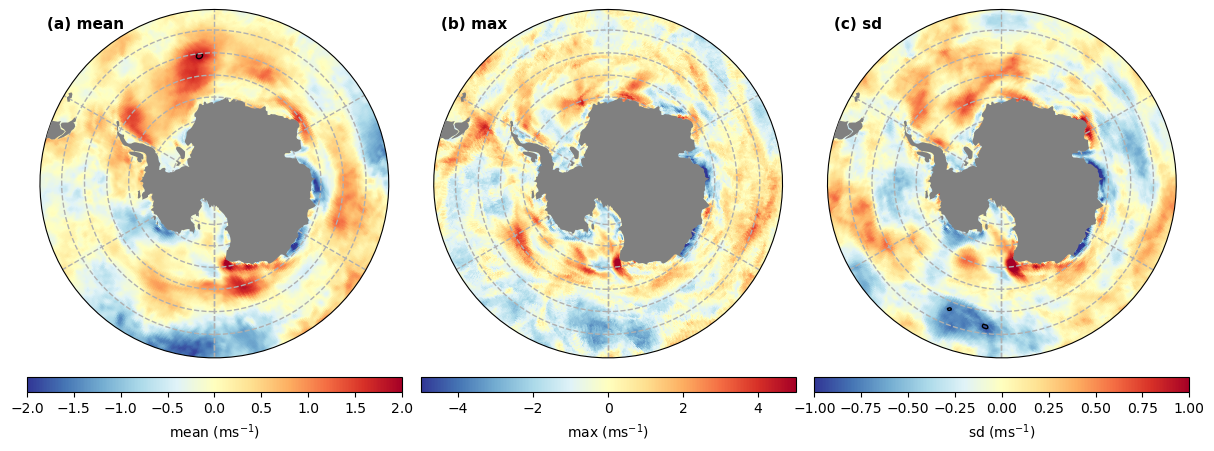

In [77]:

# PROJECTION
proj = crs.SouthPolarStereo()
data_crs = crs.PlateCarree()

# ======================
# COLOR map
# ======================



cmap = 'RdYlBu_r'
cmax=[2.,5.,1.] 


# =================
# panel set up
# ====================

nrow = 1; ncol = 3
fig, axes = plt.subplots(nrow, ncol, 
                         figsize=(15, 5),
                         subplot_kw={'projection': proj})

plt.subplots_adjust(wspace=0.05, hspace=0.05)

# Panel labels
panel_labels = ['(a) '+vars_[0], '(b) '+vars_[1], '(c) '+vars_[2]] 


# =======================
# make subplots circular
# =======================

def make_circular_boundary(ax):
    theta = np.linspace(0, 2*np.pi, 100)
    center = [0.5, 0.5]
    radius = 0.5

    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)

    ax.set_boundary(circle, transform=ax.transAxes)




# ======================
# PLOTTING LOOP
# ======================

def mapplot (panel_axes, plot_var,  maxlev):
    ax = panel_axes

    im = anom[plot_var].plot.pcolormesh(
        ax=ax,
        transform=data_crs,
        cmap=cmap,
        vmin=-maxlev,
        vmax= maxlev,
        add_colorbar=False,
        rasterized=True
    )


    anom_norm[plot_var].plot.contour(ax = ax,
                                     transform=data_crs, 
                                     colors='black', linestyles='solid', 
                                     levels=[-2.,2.], 
                                     linewidths=1.)
    
    ax.add_feature(ccrs.feature.LAND, facecolor='gray', zorder = 10)  #zorder forx=ces the land mask over the shading
    ax.gridlines(draw_labels = False, linewidth=1., linestyle='--')
    ax.set_extent([-180, 180, -90, latmax], data_crs)
    make_circular_boundary(ax)

    

for j, v in enumerate(vars_):
    mapplot(axes[j], v, cmax[j])



# ======================
# COLORBARS (horizontal, one per panel)
# ======================

for j in range(ncol):
    ax = axes[j]
    im = ax.collections[0]   # the pcolormesh

    cb = fig.colorbar(
        im,
        ax=ax,
        orientation='horizontal',
        pad=0.05,
        fraction=0.045,
        aspect = 25
    )

    cb.set_label(vars_[j]+' (ms$^{-1}$)')


# ======================
# PANEL LABELS
# ======================


for i in range(3):
    axes[i].text(
        0.02, 0.98,
        panel_labels[i],
        transform=axes[i].transAxes,
        ha='left', va='top',
        fontsize=11, fontweight='bold'
    )




plt.savefig(diro+filo)

<Figure size 640x480 with 0 Axes>